# Init

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="0"



In [2]:
from peft import (
    get_peft_model,
    LoraConfig,
    TaskType,
    prepare_model_for_int8_training,
)
from peft import PeftModel

In [3]:

import sys
import itertools
from tqdm.auto import tqdm
import pathlib
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score

import datasets
from contextlib import nullcontext
import torch
from torch import nn
from transformers import (
    Trainer,
    TrainingArguments,
    LlamaTokenizer,
    LlamaForSequenceClassification,
    TrainerCallback,
    default_data_collator,
)


import matplotlib.pyplot as plt
import seaborn as sns

from copy import deepcopy

# Load LoRA adapters

In [5]:
target_model_id =         "/bime-munin/xiruod/llama2_SHAC/n200/set-1152-quantization-epoch3-llama-2-7B-loraR-8"
source_model_id =         "/bime-munin/xiruod/llama2_SHAC/n200/Source-set-1152-quantization-epoch3-llama-2-7B-loraR-8"
reverse_source_model_id = "/bime-munin/xiruod/llama2_SHAC/n200/Reverse-Source-set-1152-quantization-epoch3-llama-2-7B-loraR-8"


In [6]:
from safetensors import safe_open

In [9]:
source_tensors = {}
reverse_source_tensors = {}

with safe_open(f"{source_model_id}/adapter_model.safetensors", framework="pt", device="cpu") as f:
    for key in f.keys():
        source_tensors[key] = f.get_tensor(key)
            

with safe_open(f"{reverse_source_model_id}/adapter_model.safetensors", framework="pt", device="cpu") as f:
    for key in f.keys():
        reverse_source_tensors[key] = f.get_tensor(key)
        

In [13]:
assert set(source_tensors.keys()) == set(reverse_source_tensors.keys())
lora_adapter_keys = list(source_tensors.keys())

# Check Similarity for A, B Separately

In [15]:
reverse_source_tensors[lora_adapter_keys[1]]

tensor([[ 1.6703e-03,  4.1517e-04,  1.6186e-03,  ..., -1.0888e-03,
         -1.4744e-03,  1.2798e-03],
        [-6.6833e-04,  7.9431e-04, -6.1413e-04,  ...,  1.0507e-03,
          8.1882e-04, -7.3330e-04],
        [ 1.2301e-04, -9.1399e-04,  1.4569e-04,  ..., -8.5621e-04,
         -3.0864e-04,  2.9504e-04],
        ...,
        [ 4.2602e-04,  2.1748e-03,  2.3567e-04,  ..., -3.2299e-04,
          2.0072e-04,  2.4294e-04],
        [ 3.9297e-05, -1.4550e-03,  1.6916e-04,  ...,  1.3122e-04,
         -3.7728e-04,  3.1037e-04],
        [ 6.2738e-04,  1.6000e-03,  6.1965e-04,  ..., -2.2172e-04,
          1.3352e-04,  7.6280e-04]])

In [14]:
source_tensors[lora_adapter_keys[1]]

tensor([[-6.2070e-04,  1.4467e-03, -7.9049e-04,  ...,  8.4957e-04,
          1.2634e-03, -5.5870e-04],
        [-5.2840e-04,  3.1946e-04, -5.2587e-05,  ...,  1.0322e-03,
          4.6864e-04, -1.9427e-04],
        [-4.6021e-04, -9.3496e-04, -4.9022e-04,  ..., -5.0715e-04,
          5.8970e-05, -4.3527e-04],
        ...,
        [ 1.1178e-03,  1.6652e-03,  4.7871e-04,  ..., -1.7270e-03,
         -1.0379e-03,  1.0149e-03],
        [-1.8212e-03,  6.2359e-04, -9.0305e-04,  ...,  1.2945e-03,
          1.5096e-03, -2.0865e-03],
        [ 1.1733e-03,  1.8655e-03,  3.1974e-04,  ..., -2.3439e-03,
         -5.1655e-04,  9.9085e-04]])

In [20]:
torch.trace(torch.matmul(torch.tensor([[1,1],[2,2]]), torch.tensor([[1,1],[2,2]]).T))

tensor(10)

In [38]:
torch.sqrt(torch.trace(torch.matmul(torch.tensor([[1,1],[2,2]]), torch.tensor([[1,1],[2,2]]).T))).numpy().item()

3.1622776985168457

In [27]:
def tensorCosine(A,B):
    return torch.trace(torch.matmul(A, B.T))/torch.sqrt(torch.trace(torch.matmul(A,A.T)) * torch.trace(torch.matmul(B,B.T)))
    

In [244]:
layer_levels = [str(x) for x in range(32)] + ['cls']

In [118]:
matrix_sims = {}
for k in lora_adapter_keys:
    matrix_sims[k] = [tensorCosine(source_tensors[k], reverse_source_tensors[k]).numpy().item()]

In [119]:
df_loras = pd.DataFrame(matrix_sims).T.reset_index()
df_loras.columns = ['layerID','cosSim']

In [246]:
df_loras['layer'] = df_loras['layerID'].apply(lambda x: str(x.split(".")[4]) if x != 'base_model.model.score.weight' else "cls")
df_loras['layer'] = pd.Categorical(df_loras['layer'], categories=layer_levels)

In [239]:
df_loras['loraProj'] = df_loras['layerID'].apply(lambda x: x.split(".")[-3] if x != 'base_model.model.score.weight' else "cls")
df_loras['loraMatrix'] = df_loras['layerID'].apply(lambda x: x.split(".")[-2] if x != 'base_model.model.score.weight' else "cls")

# Check Similairty for A*B

## paired names

In [54]:
lora_merged_keys = set([x.split(".weight")[0].replace(".lora_A","").replace(".lora_B","") for x in lora_adapter_keys])

In [55]:
len(lora_merged_keys)

65

In [75]:
merged_matrix_sims = {}

for k in lora_merged_keys:
    if k != "base_model.model.score":
        
        A_s = source_tensors[f"{k}.lora_A.weight"]
        B_s = source_tensors[f"{k}.lora_B.weight"]

        A_rs = reverse_source_tensors[f"{k}.lora_A.weight"]
        B_rs = reverse_source_tensors[f"{k}.lora_B.weight"]
    
        merged_matrix_sims[k] = [tensorCosine(torch.matmul(B_s, A_s), torch.matmul(B_rs, A_rs)).numpy().item()]
        
    else:
        
        merged_matrix_sims[k] = [tensorCosine(source_tensors[f"{k}.weight"], reverse_source_tensors[f"{k}.weight"]).numpy().item()]
        

In [268]:
df_merged = pd.DataFrame(merged_matrix_sims).T.reset_index()
df_merged.columns = ['layerID','cosSim']

In [269]:
df_merged['layer'] = df_merged['layerID'].apply(lambda x: str(x.split(".")[4]) if x != 'base_model.model.score' else "cls")
df_merged['layer'] = pd.Categorical(df_merged['layer'], categories=layer_levels)

In [270]:
df_merged['loraProj'] = df_merged['layerID'].apply(lambda x: x.split(".")[-1] if x != 'base_model.model.score' else "cls")

# Visualize

In [260]:
plt.style.use('ggplot')

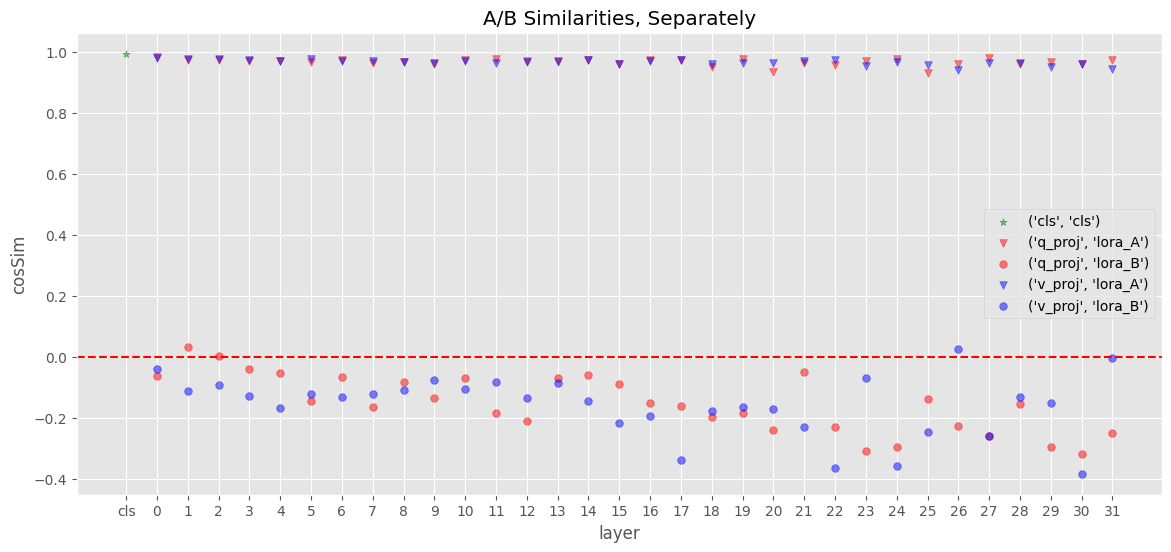

In [279]:
coldict={'q_proj':'red','v_proj':'blue','cls':'green'}
markdict={'lora_A':'v','lora_B':'o','cls':'*'}


grouped = df_loras.groupby(['loraProj','loraMatrix'])

fig, ax = plt.subplots(figsize=(14, 6))


for key, group in grouped:
    group.sort_values('layer').plot(ax=ax, kind='scatter', x='layer', y='cosSim', label=key, color=coldict[key[0]], marker=markdict[key[1]], alpha=0.5, s=30)
    # plt.xticks(np.arange(len(group)), group['layer'], rotation=90) 

plt.axhline(y=0, color='red', ls='--')
plt.title("A/B Similarities, Separately")

plt.show()


In [272]:
key

('v_proj',)

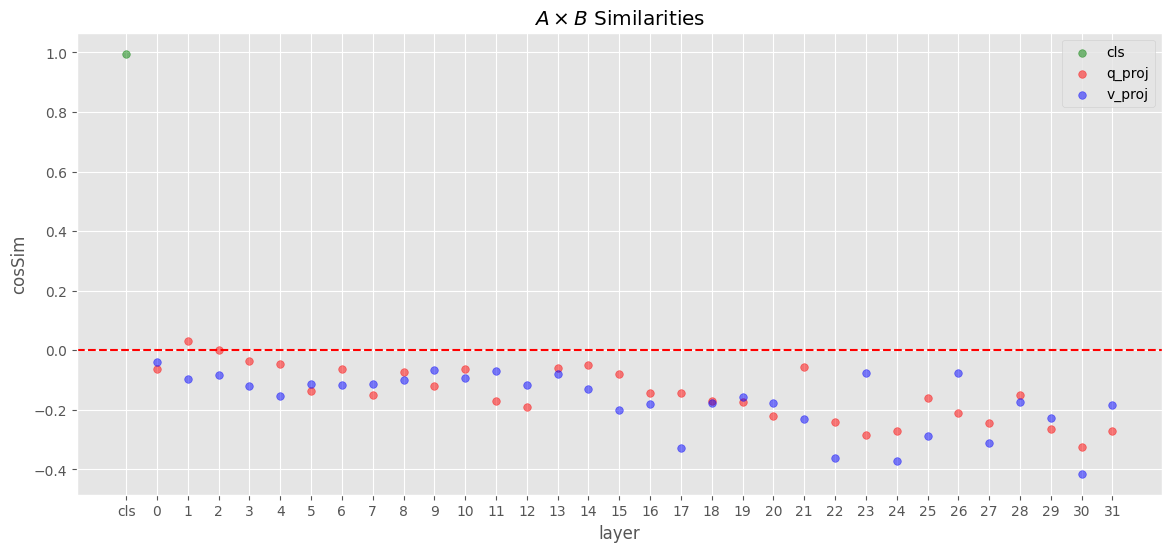

In [278]:
coldict={'q_proj':'red','v_proj':'blue','cls':'green'}
# markdict={'lora_A':'v','lora_B':'o','cls':'*'}


grouped = df_merged.groupby(['loraProj'])

fig, ax = plt.subplots(figsize=(14, 6))


for key, group in grouped:
    group.sort_values('layer').plot(ax=ax, kind='scatter', x='layer', y='cosSim', label=key[0], color=coldict[key[0]], 
                                    # marker=markdict[key[1]], 
                                    alpha=0.5, s=30)
    # plt.xticks(np.arange(len(group)), group['layer'], rotation=90) 

plt.axhline(y=0, color='red', ls='--')
plt.title(r"$A \times B$ Similarities")
plt.show()
